# COSETTE & MARIUS: reproduction and extension

This notebook presents the project end to end: a reproduction of *Closing the Performance Gap in Generative Recommenders with Collaborative Tokenization and Efficient Modeling* (Lepage, Mary, Picard; arXiv:2508.14910), a beyond-accuracy audit of the trained models, an analysis of a failure mode the audit surfaced, and four pilot interventions.

All figures are computed from committed artifacts in this repository. Model accuracy comes from the authors' unmodified evaluation code; the beyond-accuracy metrics are recomputed from the models' own ranked outputs and match the official Recall@10 to the decimal.

1. The paper and its claims
2. Reproduction
3. Beyond-accuracy audit
4. Reachability: the collapse mechanism
5. MBR re-ranking
6. Conformal prediction sets
7. Fusion ablation
8. Synthesis

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / 'scripts' / 'extensions' / 'beyond_accuracy.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
from scripts.extensions import beyond_accuracy as ba
from scripts.extensions.compute_beyond_accuracy import load_support, load_model_recs

RES = REPO / 'reports' / 'results'
FAITH = REPO / 'reports' / 'paper_faithful_rerun'
EXT = REPO / 'reports' / 'extensions'
CATS = ['Beauty', 'Sports_and_Outdoors']
SHORT = {'Beauty': 'Beauty', 'Sports_and_Outdoors': 'Sports'}

# A single muted palette, used consistently throughout.
SAS, MAR = '#4c72b0', '#c44e52'          # the two models
NEUTRAL, ACCENT, MUTE = '#8c8c8c', '#55a868', '#b0b0b0'
COL = {'sasrec': SAS, 'marius': MAR}

mpl.rcParams.update({
    'figure.dpi': 120, 'savefig.bbox': 'tight', 'figure.facecolor': 'white',
    'font.size': 10, 'axes.titlesize': 10.5, 'axes.labelsize': 9.5,
    'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5, 'legend.fontsize': 8.5,
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False, 'axes.titlelocation': 'left', 'axes.titlepad': 8,
})

def tidy(ax, ygrid=True):
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    if ygrid:
        ax.yaxis.grid(True, color='#e6e6e6', lw=0.8)
    return ax

def labels(ax, xs, vals, fmt='{:.2f}', dy=0.0):
    for x, v in zip(np.atleast_1d(xs), np.atleast_1d(vals)):
        ax.annotate(fmt.format(v), (x, v + dy), ha='center', va='bottom',
                    fontsize=7.5, color='#555')

def jsonl_r10(path):
    rows = [json.loads(l) for l in Path(path).read_text().splitlines() if l.strip()]
    vals = [r['R@10'] for r in rows if r.get('status') == 'ok']
    return float(np.mean(vals)), (float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0)

PAPER = {'Beauty': {'sasrec': 9.73, 'marius': 10.02},
         'Sports_and_Outdoors': {'sasrec': 6.44, 'marius': 6.72}}

## 1. The paper

The paper has two parts. COSETTE assigns each item a four-digit *semantic ID* with an RQ-VAE over text embeddings, adding a contrastive term so that co-consumed items receive similar codes. MARIUS is a lightweight generative recommender: a temporal transformer reads the user's history (one fused token per past item), and a depth transformer writes the next item's four code digits autoregressively, with beam search returning the top candidates.

The paper reports that MARIUS is much faster than the prior generative model (TIGER), beats the tuned discriminative baseline SASRec++ at large scale, and is competitive with it at small scale (Table 5: Beauty Recall@10 10.02 vs 9.73). The mandatory reproduction tests the small-scale claim on Beauty and Sports.

## 2. Reproduction

Running the repository as released places every metric 15 to 28 percent below the paper. The main cause is a configuration difference: the paper selects the baseline size per dataset (appendix Figure 11a; Beauty's best is d=32 with no normalization), while the repository ships only its default (d=128 with L2 normalization). Using the paper's configuration recovers roughly 55 percent of the Beauty gap, from 8.24 to 9.06.

MARIUS already uses the paper's configuration, yet the faithful baseline clearly exceeds it (9.06 vs 8.17 on Beauty). The small-scale competitiveness claim does not reproduce here. Undertraining, the data split, the evaluation code, batch size, and tokenizer quality were ruled out; the validation curve below shows the model converges and mildly overfits rather than stopping early.

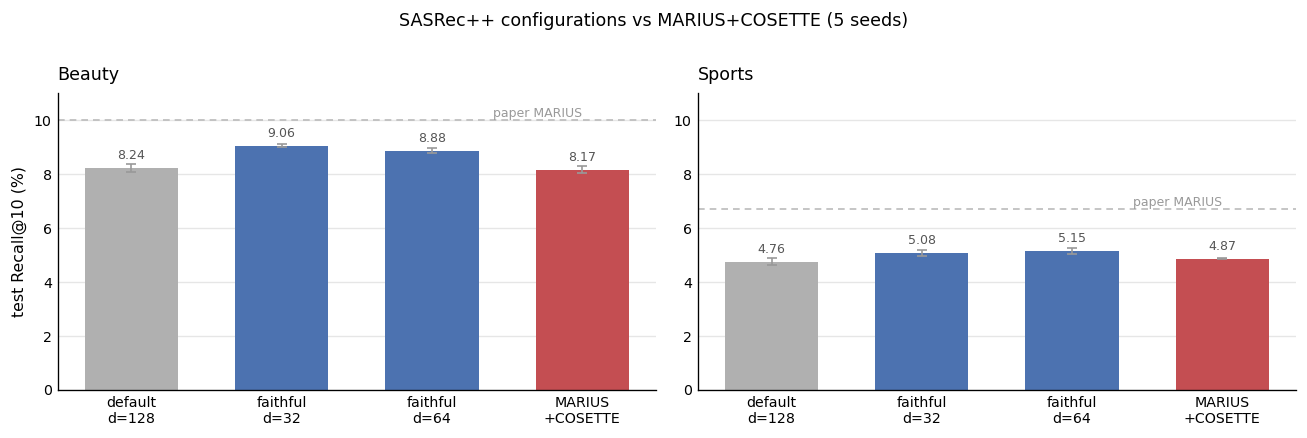

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, cat, slug in zip(axes, CATS, ['beauty', 'sports']):
    bars = [
        ('default\nd=128', jsonl_r10(RES / f'sasrec_{slug}_5seed_full_scores.jsonl'), MUTE),
        ('faithful\nd=32', jsonl_r10(FAITH / f'{slug}_d32__scores.jsonl'), SAS),
        ('faithful\nd=64', jsonl_r10(FAITH / f'{slug}_d64__scores.jsonl'), SAS),
        ('MARIUS\n+COSETTE', jsonl_r10(RES / f'marius_{slug}_5seed_full_scores.jsonl'), MAR),
    ]
    x = np.arange(len(bars))
    means = [b[1][0] for b in bars]
    ax.bar(x, means, 0.62, yerr=[b[1][1] for b in bars], color=[b[2] for b in bars],
           ecolor='#999', capsize=3, error_kw={'lw': 1})
    labels(ax, x, means, dy=0.22)
    ax.axhline(PAPER[cat]['marius'], color='#bbb', ls=(0, (4, 3)), lw=1)
    ax.text(len(bars) - 1, PAPER[cat]['marius'] + 0.1, 'paper MARIUS', ha='right',
            fontsize=7.5, color='#999')
    ax.set_xticks(x); ax.set_xticklabels([b[0] for b in bars])
    ax.set_ylim(0, 11); ax.set_title(SHORT[cat])
    tidy(ax)
axes[0].set_ylabel('test Recall@10 (%)')
fig.suptitle('SASRec++ configurations vs MARIUS+COSETTE (5 seeds)', x=0.5, y=1.0, fontsize=10.5)
plt.tight_layout(); plt.show()

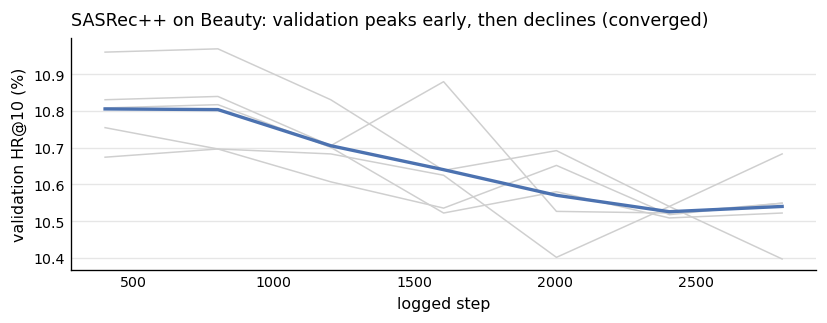

In [3]:
fig, ax = plt.subplots(figsize=(7, 2.8))
frames = []
for seed in [42, 43, 44, 45, 46]:
    df = pd.read_csv(REPO / 'reports' / 'metrics' / f'sasrec_Beauty_seed{seed}.csv')
    df = df[df.metric == 'HR@10']
    ax.plot(df.step, 100 * df.value, color='#cfcfcf', lw=0.9)
    frames.append(df.set_index('step')['value'])
mean = 100 * pd.concat(frames, axis=1).mean(axis=1)
ax.plot(mean.index, mean.values, color=SAS, lw=2)
ax.set_xlabel('logged step'); ax.set_ylabel('validation HR@10 (%)')
ax.set_title('SASRec++ on Beauty: validation peaks early, then declines (converged)')
tidy(ax)
plt.tight_layout(); plt.show()

## 3. Beyond-accuracy audit

Accuracy is only part of the picture. From the models' ranked top-10 lists we also measure catalog coverage (the fraction of items ever recommended), the Gini coefficient of exposure (concentration), and the share of recommendations falling in each item-popularity decile.

The two datasets give opposite pictures. On Beauty, MARIUS spreads exposure more evenly than the baseline and leans less on the most popular items. On the sparser Sports catalog this reverses: coverage falls to 0.39 and concentration exceeds the baseline. On both datasets MARIUS's tail recall is lower, so the Beauty diversity reflects redistributed exposure rather than more accurate tail predictions.

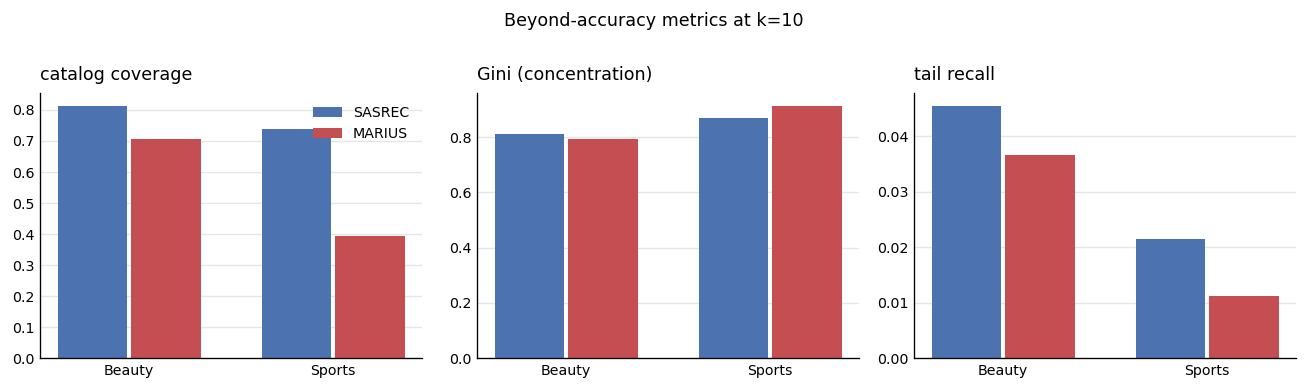

In [4]:
audit = pd.concat([pd.read_csv(EXT / f'beyond_accuracy_{c}.csv') for c in CATS])
a10 = audit[audit.k == 10].set_index(['category', 'model'])
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
panels = [('coverage_mean', 'catalog coverage', '{:.2f}'),
          ('gini_mean', 'Gini (concentration)', '{:.2f}'),
          ('tail_recall_mean', 'tail recall', '{:.3f}')]
for ax, (metric, title, fmt) in zip(axes, panels):
    x = np.arange(len(CATS))
    for i, m in enumerate(['sasrec', 'marius']):
        vals = [a10.loc[(c, m), metric] for c in CATS]
        ax.bar(x + (i - 0.5) * 0.36, vals, 0.34, color=COL[m],
               label=m.upper() if ax is axes[0] else None)
    ax.set_xticks(x); ax.set_xticklabels([SHORT[c] for c in CATS]); ax.set_title(title)
    tidy(ax)
axes[0].legend(loc='upper right')
fig.suptitle('Beyond-accuracy metrics at k=10', x=0.5, y=1.0, fontsize=10.5)
plt.tight_layout(); plt.show()

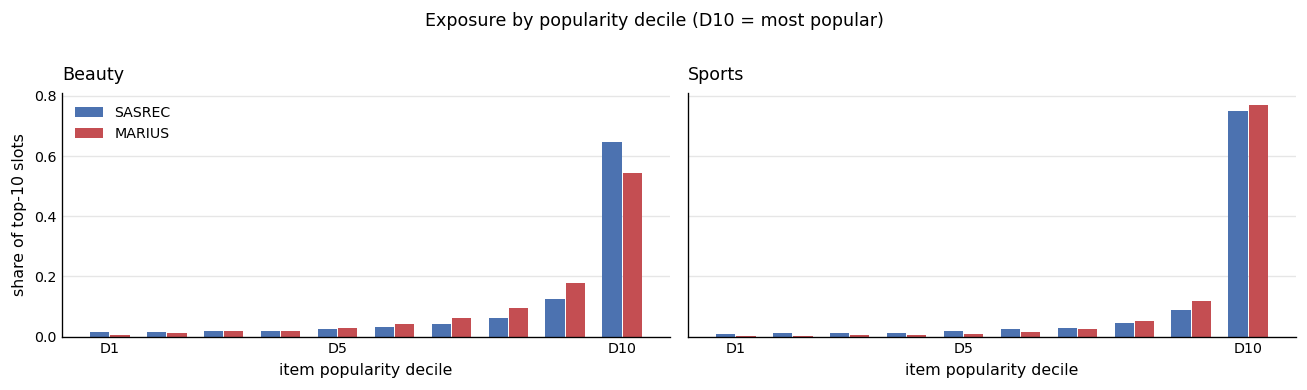

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, cat in zip(axes, CATS):
    meta, pop, _, t2i = load_support(EXT / 'topk' / cat)
    x = np.arange(10)
    for i, m in enumerate(['sasrec', 'marius']):
        profs = [ba.popularity_decile_exposure(load_model_recs(EXT / 'topk' / cat, m, s, meta, t2i)[0], pop, k=10)
                 for s in [42, 43, 44]]
        ax.bar(x + (i - 0.5) * 0.36, np.mean(profs, axis=0), 0.34, color=COL[m],
               label=m.upper() if ax is axes[0] else None)
    ax.set_xticks([0, 4, 9]); ax.set_xticklabels(['D1', 'D5', 'D10'])
    ax.set_xlabel('item popularity decile'); ax.set_title(SHORT[cat])
    tidy(ax)
axes[0].set_ylabel('share of top-10 slots'); axes[0].legend(loc='upper left')
fig.suptitle('Exposure by popularity decile (D10 = most popular)', x=0.5, y=1.0, fontsize=10.5)
plt.tight_layout(); plt.show()

## 4. Reachability: the collapse mechanism

A generative recommender can only recommend an item whose code its beam writes. On Sports, half the catalog (9,260 items) is never written by any seed; those items carry 22 percent of all training interactions, against 5.7 percent for the baseline's unreached set.

The pruning happens at the second code digit, not the first: all 256 first digits are used, but digit pairs that are never written cover 26 percent of the Sports catalog and account for half the unreachable items. The strongest predictor of unreachability is an item's popularity share within its first-digit family (point-biserial r = -0.62), ahead of its own popularity (-0.58): items are pruned in favour of stronger siblings sharing their prefix. A second, independently trained Sports tokenizer reproduces these numbers within one to two points.

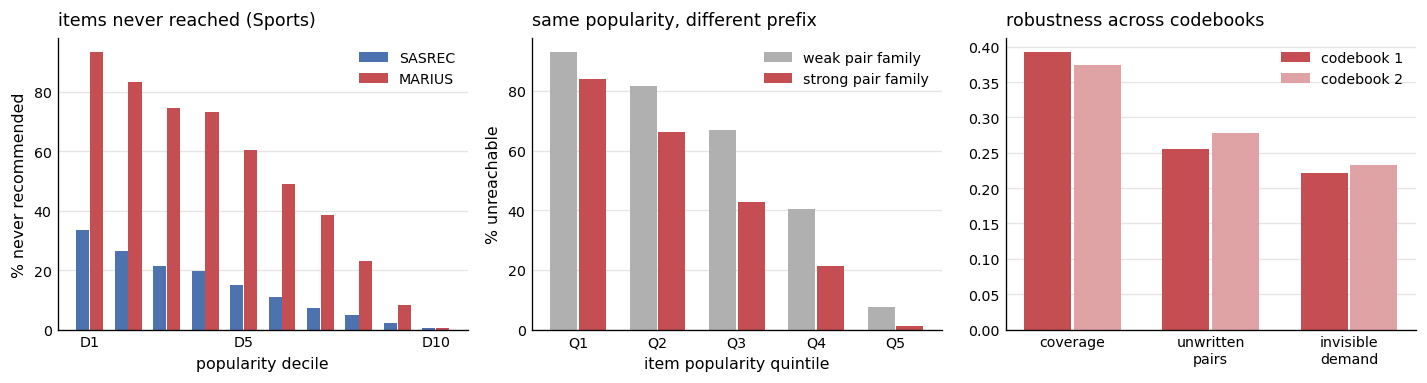

In [6]:
reach = {c: json.loads((EXT / 'reach' / f'reach_results_{c}.json').read_text()) for c in CATS}
cb2 = json.loads((EXT / 'reach_cb2' / 'reach_results_Sports_and_Outdoors.json').read_text())
fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))

rows = reach['Sports_and_Outdoors']['structure']['decile_rows']
x = np.arange(10)
for i, m in enumerate(['sasrec', 'marius']):
    axes[0].bar(x + (i - 0.5) * 0.36, [100 * r[f'{m}_unreached_frac'] for r in rows], 0.34,
                color=COL[m], label=m.upper())
axes[0].set_xticks([0, 4, 9]); axes[0].set_xticklabels(['D1', 'D5', 'D10'])
axes[0].set_xlabel('popularity decile'); axes[0].set_ylabel('% never recommended')
axes[0].set_title('items never reached (Sports)'); axes[0].legend(); tidy(axes[0])

t = reach['Sports_and_Outdoors']['mechanism']['table_l12']
xq = np.arange(5)
axes[1].bar(xq - 0.18, [100 * r['unreached_low'] for r in t], 0.34, color=MUTE, label='weak pair family')
axes[1].bar(xq + 0.18, [100 * r['unreached_high'] for r in t], 0.34, color=MAR, label='strong pair family')
axes[1].set_xticks(xq); axes[1].set_xticklabels([f'Q{r["quintile"]}' for r in t])
axes[1].set_xlabel('item popularity quintile'); axes[1].set_ylabel('% unreachable')
axes[1].set_title('same popularity, different prefix'); axes[1].legend(); tidy(axes[1])

m1, m2 = reach['Sports_and_Outdoors'], cb2
names = ['coverage', 'unwritten\npairs', 'invisible\ndemand']
v1 = [m1['reach']['marius_k10']['mean_reached_frac'], m1['mechanism']['pair_never_emitted_frac'],
      m1['structure']['demand_mass_share_unreached']]
v2 = [m2['reach']['marius_k10']['mean_reached_frac'], m2['mechanism']['pair_never_emitted_frac'],
      m2['structure']['demand_mass_share_unreached']]
xv = np.arange(3)
axes[2].bar(xv - 0.18, v1, 0.34, color=MAR, label='codebook 1')
axes[2].bar(xv + 0.18, v2, 0.34, color='#e0a3a5', label='codebook 2')
axes[2].set_xticks(xv); axes[2].set_xticklabels(names)
axes[2].set_title('robustness across codebooks'); axes[2].legend(); tidy(axes[2])
plt.tight_layout(); plt.show()

## 5. MBR re-ranking

The first intervention leaves the model frozen and changes only how the beam's candidates are ranked. Minimum-Bayes-risk re-ranking prefers candidates that agree with the model's other guesses (measured by shared code-prefix length), weighted by the model's own confidence at temperature tau.

MBR does not improve accuracy: the original beam order remains best on Recall@10. It does provide a serving-time trade-off between accuracy and reach. On Sports, giving up 0.6 points of Recall@10 raises coverage from 0.39 to 0.52, lowers average recommendation popularity from 101 to 73, and improves tail recall by about a third (at every tau tested).

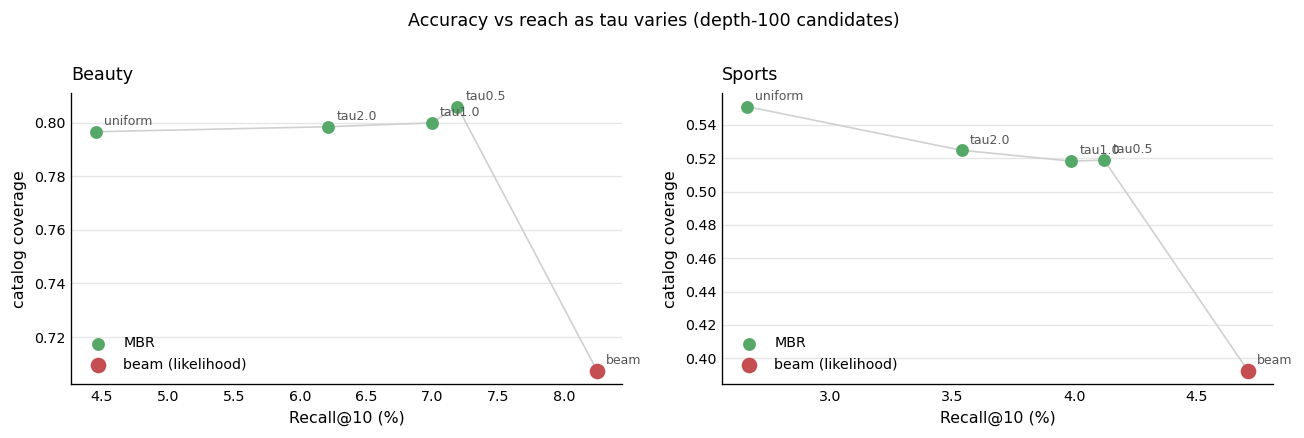

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, cat in zip(axes, CATS):
    pts = {}
    for var in ['uniform', 'tau0.5', 'tau1.0', 'tau2.0']:
        df = pd.read_csv(EXT / 'mbr' / f'mbr_{cat}_d100_{var}.csv')
        m = df.groupby('variant')[['recall', 'coverage']].mean()
        pts['beam'] = m.loc['original']; pts[var] = m.loc['mbr']
    order = ['beam', 'tau0.5', 'tau1.0', 'tau2.0', 'uniform']
    xs = [pts[p]['recall'] * 100 for p in order]; ys = [pts[p]['coverage'] for p in order]
    ax.plot(xs, ys, '-', color='#d0d0d0', lw=1, zorder=1)
    ax.scatter(xs[1:], ys[1:], s=45, color=ACCENT, zorder=3, label='MBR')
    ax.scatter(xs[0], ys[0], s=70, color=MAR, zorder=4, label='beam (likelihood)')
    for p, xp, yp in zip(order, xs, ys):
        ax.annotate(p, (xp, yp), textcoords='offset points', xytext=(5, 4), fontsize=7.5, color='#555')
    ax.set_xlabel('Recall@10 (%)'); ax.set_ylabel('catalog coverage'); ax.set_title(SHORT[cat])
    ax.legend(loc='lower left'); tidy(ax)
fig.suptitle('Accuracy vs reach as tau varies (depth-100 candidates)', x=0.5, y=1.0, fontsize=10.5)
plt.tight_layout(); plt.show()

## 6. Conformal prediction sets

The second intervention returns a set calibrated to contain the true next item with a chosen frequency (split conformal on the target's rank). With one held-out item per user, the guaranteeable coverage is bounded by Recall@depth, so the practical use is small sets with modest guarantees plus a per-user uncertainty signal: calibrating separately by history length, cold users receive visibly larger sets (about 3.4x on Beauty).

The coverage ceilings reveal a crossover. At depth 20 the baseline's ceiling is higher, but at depth 100 MARIUS's is higher on both datasets. MARIUS's deeper candidate pool is the stronger one; the ranking of the top of its list is what limits it, which is consistent with the MBR result above.

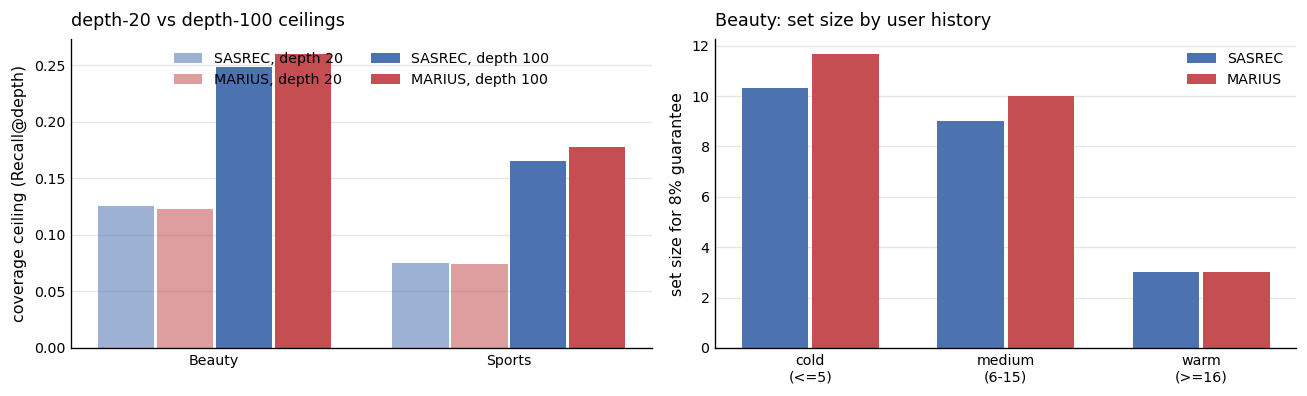

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
x = np.arange(2)
specs = [(20, 'conformal', 'ceiling_recall20_all', 0.55),
         (100, 'conformal_d100', 'ceiling_recall_all', 1.0)]
for j, (depth, dirname, colname, alpha) in enumerate(specs):
    for i, m in enumerate(['sasrec', 'marius']):
        vals = [pd.read_csv(EXT / dirname / f'split_conformal_{c}.csv').query('model == @m')[colname].mean()
                for c in CATS]
        off = (j * 2 + i - 1.5) * 0.2
        axes[0].bar(x + off, vals, 0.19, color=COL[m], alpha=alpha,
                    label=f'{m.upper()}, depth {depth}')
axes[0].set_xticks(x); axes[0].set_xticklabels([SHORT[c] for c in CATS])
axes[0].set_ylabel('coverage ceiling (Recall@depth)')
axes[0].set_title('depth-20 vs depth-100 ceilings'); axes[0].legend(ncol=2, loc='upper center')
tidy(axes[0])

mo = pd.read_csv(EXT / 'conformal' / 'mondrian_Beauty.csv')
mo = mo[(mo.target_coverage == 0.08) & mo.achievable]
buckets = ['hist<=5', 'hist6-15', 'hist>=16']
xb = np.arange(3)
for i, m in enumerate(['sasrec', 'marius']):
    g = mo[mo.model == m].groupby('bucket')['k_star'].mean().reindex(buckets)
    axes[1].bar(xb + (i - 0.5) * 0.36, g.values, 0.34, color=COL[m], label=m.upper())
axes[1].set_xticks(xb); axes[1].set_xticklabels(['cold\n(<=5)', 'medium\n(6-15)', 'warm\n(>=16)'])
axes[1].set_ylabel('set size for 8% guarantee')
axes[1].set_title('Beauty: set size by user history'); axes[1].legend(); tidy(axes[1])
plt.tight_layout(); plt.show()

## 7. Fusion ablation

MARIUS combines an item's four code embeddings into one history token by summing them, a choice inherited from audio models that ignores which digit carried the information. We replaced the sum with level-aware alternatives (a per-level gain, and a small attention over the four digits), in a subclass that leaves the authors' code untouched and matches the baseline exactly at initialization, then retrained on Beauty (3 seeds).

Accuracy is unchanged: the fusion is not the bottleneck, which concentrates the remaining evidence on the decoding stage. The per-level gain variant does shift every beyond-accuracy metric slightly in the favourable direction at no accuracy cost.

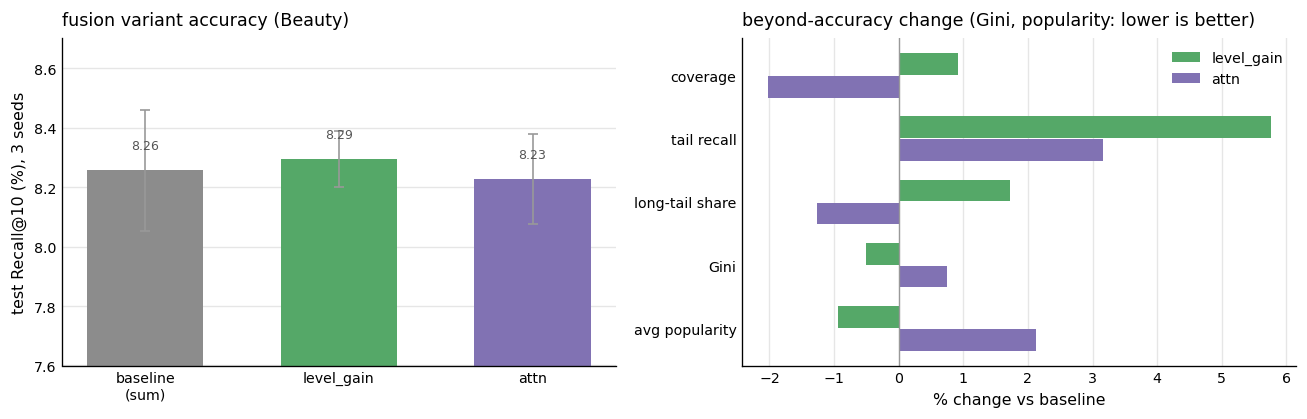

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
arms = [('baseline\n(sum)', EXT / 'baseline_scur1217' / 'marius_beauty_5seed_full_scores.jsonl', NEUTRAL),
        ('level_gain', EXT / 'fuse' / 'level_gain' / 'marius_beauty_5seed_full_scores.jsonl', ACCENT),
        ('attn', EXT / 'fuse' / 'attn' / 'marius_beauty_5seed_full_scores.jsonl', '#8172b3')]
means = []
for xi, (label, path, c) in enumerate(arms):
    mean, std = jsonl_r10(path); means.append(mean)
    axes[0].bar(xi, mean, 0.6, yerr=std, color=c, ecolor='#999', capsize=3, error_kw={'lw': 1})
labels(axes[0], range(3), means, dy=0.06)
axes[0].set_xticks(range(3)); axes[0].set_xticklabels([a[0] for a in arms])
axes[0].set_ylabel('test Recall@10 (%), 3 seeds'); axes[0].set_ylim(7.6, 8.7)
axes[0].set_title('fusion variant accuracy (Beauty)'); tidy(axes[0])

base = pd.read_csv(EXT / 'beyond_accuracy_Beauty.csv')
b = base[(base.model == 'marius') & (base.k == 10)].iloc[0]
metrics = [('coverage_mean', 'coverage'), ('tail_recall_mean', 'tail recall'),
           ('aplt_mean', 'long-tail share'), ('gini_mean', 'Gini'), ('arp_mean', 'avg popularity')]
y = np.arange(len(metrics))
for i, (arm, c) in enumerate([('level_gain', ACCENT), ('attn', '#8172b3')]):
    df = pd.read_csv(EXT / 'fuse' / f'beyond_accuracy_Beauty_{arm}.csv')
    row = df[df.k == 10].iloc[0]
    rel = [100 * (row[mc] - b[mc]) / b[mc] for mc, _ in metrics]
    axes[1].barh(y + (i - 0.5) * 0.36, rel, 0.34, color=c, label=arm)
axes[1].axvline(0, color='#999', lw=0.8)
axes[1].set_yticks(y); axes[1].set_yticklabels([lbl for _, lbl in metrics])
axes[1].set_xlabel('% change vs baseline'); axes[1].invert_yaxis()
axes[1].set_title('beyond-accuracy change (Gini, popularity: lower is better)')
axes[1].legend(); tidy(axes[1], ygrid=False); axes[1].xaxis.grid(True, color='#e6e6e6', lw=0.8)
plt.tight_layout(); plt.show()

## 8. Synthesis

The results form a single line of argument about catalog collapse in semantic-ID generative recommenders.

| Question | Evidence |
|---|---|
| Is there a failure mode? | The diversity profile inverts with dataset density; Sports coverage is 0.39 vs 0.74. |
| Does it matter? | 22 to 23% of training demand is never recommended by the generative model. |
| Why does it happen? | Weak code-pair families are pruned at the second digit; items lose to prefix siblings (r = -0.62). Robust across two codebooks. |
| Where is the cause? | Not the fusion (ablation is null); the decoding stage (the depth-100 ceiling crossover). |
| What helps already? | MBR gives a tunable accuracy-vs-reach trade-off; conformal sets give guarantees and a usable uncertainty signal. |
| What is still open? | A decoder that targets the mechanism directly, adding exploration at the second digit, aiming to improve on the MBR trade-off. |

A natural extension is the scale axis: with a fixed 256-way codebook, the number of items per prefix grows with the catalog, so the mechanism predicts the collapse should worsen on the large Amazon-2023 datasets even as accuracy improves. This remains untested.

The reproduction is on `main`; all extension code, dumps, and results are on the `stanislaw` branch, with provenance documented in `CODE_OVERVIEW.md`.